### 1. Carrega bibliotecas que serão utilizadas

In [1]:
%pip install pandas
%pip install pyspark
%pip install numpy
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached pyspark-4.1.2.tar.gz (455.4 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached py4j-0.10.9.9-py2.py3-none-any.whl.metadata (1.3 kB)
Using cached py4j-0.10.9.9-py2.py3-none-any.whl (203 kB)
  Created wheel for pyspark: filename=pyspark-4.1.2-py2.py3-none-any.whl size=456178792 sha256=ea15165440e61783ea49c3f96e74d1fc096d4e1c9b43ea591418c30abe501e51
  Stored in directory: c:\users\usuario\appdata\local\pip\cache\wheels\c8\b6\55\ad8ce5b69e0b2dd1e6fe41f668eb4e18bc436fd42068364bad
Successfully built pyspark

   ---------------------------------------- 0/2 [py4j]
   ---------------------------------------- 0/2 [py4j]
   ---------------------------------------- 0/2 [py4j]
   -----------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   --------- ------------------------------ 2.4/9.5 MB 12.1 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.5 MB 13.1 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.5 MB 13.7 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 13.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 13.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 13.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 13.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 13.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 13.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 13.9 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 13.9 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 3.8 MB/s  0:00:02
   --------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2. Carrega a base do kaggle

In [2]:
from pyspark import SparkConf
from pyspark.sql import SparkSession
from pyspark.sql import functions as f
from pyspark.sql import Row, DataFrame
from pyspark.sql.types import StringType, StructType, StructField, IntegerType
from pyspark.sql.functions import col, expr, lit, substring, concat, concat_ws, when, coalesce, sum, avg
from functools import reduce
import pandas as pd
import numpy as np
import calendar
import subprocess
import os, getpass
from getpass import getuser
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
from dateutil.relativedelta import relativedelta
warnings.filterwarnings('ignore')

%pip install kaggle
from kaggle.api.kaggle_api_extended import KaggleApi
import sys
api = KaggleApi()
api.authenticate()
api.dataset_download_files("yasserh/wine-quality-dataset", path=".")
import zipfile
with zipfile.ZipFile("wine-quality-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

Matplotlib is building the font cache; this may take a moment.

[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Dataset URL: https://www.kaggle.com/datasets/yasserh/wine-quality-dataset


### 3. Transforma o arquivo csv importanto em um dataframe

In [3]:
import zipfile
import pandas as pd

path_to_zip = "wine-quality-dataset.zip"

with zipfile.ZipFile(path_to_zip) as zip_ref:
    with zip_ref.open("WineQT.csv") as f:
        df_wineqt_0 = pd.read_csv(f)

### 4. Avaliação se todos os campos estão preenchidos.

In [4]:
df_wineqt_0.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

### 5. Cria coluna quality_category:
● Vinho de Alta Qualidade: nota ≥ 7 ● Vinho de Baixa/Média Qualidade: nota < 7

In [5]:
df_wineqt_1 = df_wineqt_0.copy()
df_wineqt_1['quality_category'] = df_wineqt_0['quality'].apply(lambda x: 'High Quality Wine' if x >= 7 else 'Low/Medium Quality Wine')

### 6. Teste algumas variaveis numéricas

In [6]:
df_wineqt_1['fixed acidity'].max()

np.float64(15.9)

In [7]:
df_wineqt_1['alcohol'].max()

np.float64(14.9)

In [8]:
df_wineqt_1['free sulfur dioxide'].max()

np.float64(68.0)

In [9]:
df_wineqt_1['total sulfur dioxide'].max()

np.float64(289.0)

In [10]:
df_wineqt_1['density'].max()

np.float64(1.00369)

In [11]:
df_wineqt_1['pH'].max()

np.float64(4.01)

### Distribuição de Vinhos por Categoria de Qualidade

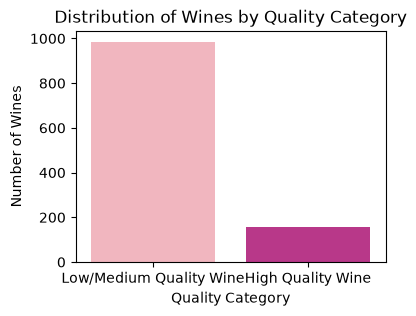

In [15]:
plt.figure(figsize=(4, 3))
sns.countplot(x='quality_category', data=df_wineqt_1, palette='RdPu')
plt.title('Distribution of Wines by Quality Category')
plt.xlabel('Quality Category')
plt.ylabel('Number of Wines')
plt.show()

### Criação da Coluna 'faixa teor alcoolico'

Esta coluna categoriza os vinhos com base no seu teor alcoólico:
- **8.4% a 10%**
- **10.1% a 12%**
- **12.1% a 14.9%**

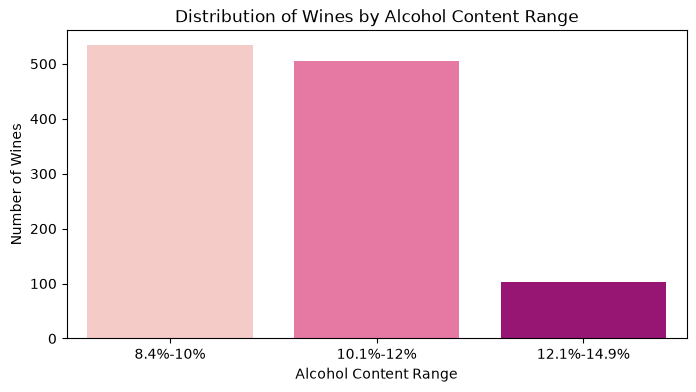

In [17]:
bins = [8.3, 10, 12, 14.9]
labels = ['8.4%-10%', '10.1%-12%', '12.1%-14.9%']
df_wineqt_1['faixa teor alcoolico'] = pd.cut(df_wineqt_1['alcohol'], bins=bins, labels=labels, right=True)
plt.figure(figsize=(8, 4))
sns.countplot(x='faixa teor alcoolico', data=df_wineqt_1, palette='RdPu', order=labels)
plt.title('Distribution of Wines by Alcohol Content Range')
plt.xlabel('Alcohol Content Range')
plt.ylabel('Number of Wines')
plt.show()

### Criação da Coluna 'faixa de pH'

Esta coluna categoriza os vinhos com base no seu nível de pH:
- **2.74 a 3.00**
- **3.01 a 3.25**
- **3.26 a 3.50**
- **3.51 a 3.75**
- **3.76 a 4.01**

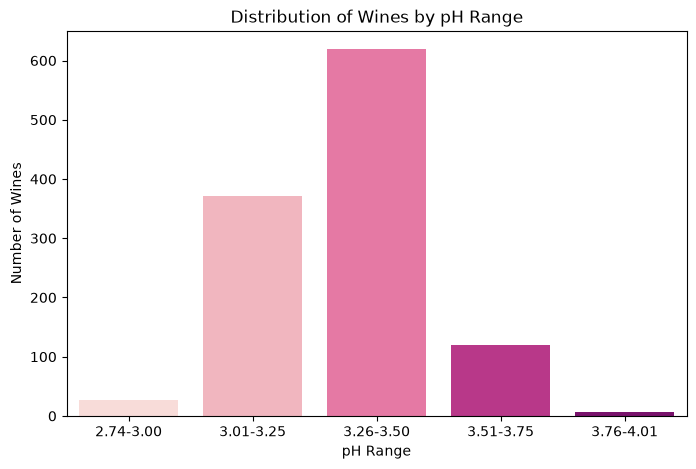

In [19]:
pH_bins = [2.73, 3.00, 3.25, 3.50, 3.75, 4.01]
pH_labels = ['2.74-3.00', '3.01-3.25', '3.26-3.50', '3.51-3.75', '3.76-4.01']
df_wineqt_1['faixa de ph'] = pd.cut(df_wineqt_1['pH'], bins=pH_bins, labels=pH_labels, right=True)
plt.figure(figsize=(8, 5))
sns.countplot(x='faixa de ph', data=df_wineqt_1, palette='RdPu', order=pH_labels)
plt.title('Distribution of Wines by pH Range')
plt.xlabel('pH Range')
plt.ylabel('Number of Wines')
plt.show()

Perc. Acido Citrico possui outliers, registro foi excluido para não prejudicar analise

In [20]:
df_wineqt_2 = df_wineqt_1[df_wineqt_1['citric acid'] != 1].copy()

print(f"Número de linhas em df_wineqt_1: {len(df_wineqt_1)}")
print(f"Número de linhas em df_wineqt_2 (sem citric acid = 1): {len(df_wineqt_2)}")

Número de linhas em df_wineqt_1: 1143
Número de linhas em df_wineqt_2 (sem citric acid = 1): 1142


### Criação da Coluna 'faixa de acidez fixa'

Esta coluna categoriza os vinhos com base na sua acidez fixa:
- **4.6 - 6**
- **6.1 - 7**
- **7.1 - 8**
- **8.1 - 9**
- **9.1 - 10**
- **10.1 - 11**
- **11.1 - 13**
- **13.1 - 15.9**

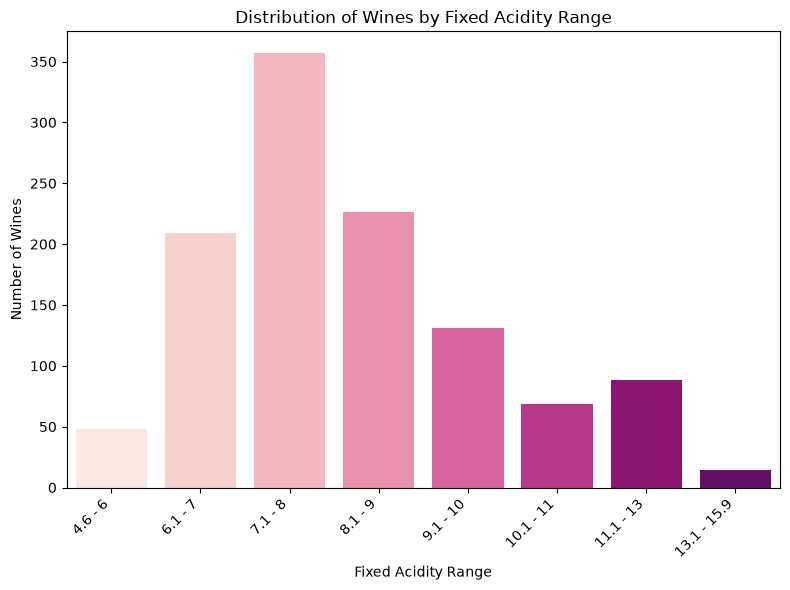

In [21]:
fixed_acidity_bins = [4.5, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 13.0, 15.9]
fixed_acidity_labels = ['4.6 - 6', '6.1 - 7', '7.1 - 8', '8.1 - 9', '9.1 - 10', '10.1 - 11', '11.1 - 13', '13.1 - 15.9']
df_wineqt_2['faixa de acidez fixa'] = pd.cut(df_wineqt_2['fixed acidity'], bins=fixed_acidity_bins, labels=fixed_acidity_labels, right=True)
plt.figure(figsize=(8, 6))
sns.countplot(x='faixa de acidez fixa', data=df_wineqt_2, palette='RdPu', order=fixed_acidity_labels)
plt.title('Distribution of Wines by Fixed Acidity Range')
plt.xlabel('Fixed Acidity Range')
plt.ylabel('Number of Wines')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Criação da Coluna 'faixa de distribuicao de acucar residual'

Esta coluna categoriza os vinhos com base no seu percentual de açúcar residual:
- **0.9 à 2**
- **2.1 à 3**
- **3.1 à 4**
- **4.1 à 5**
- **5.1 à 6**
- **6 à 7**
- **8 à 10**
- **Acima de 10**

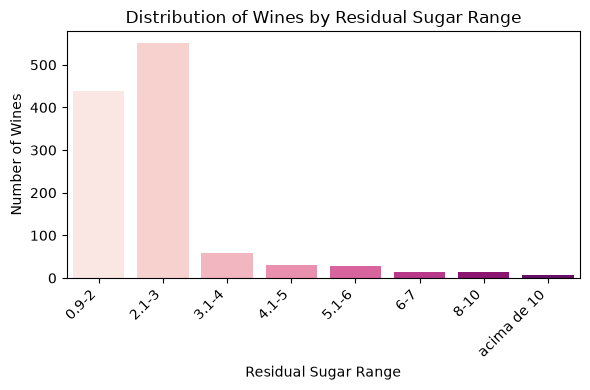

In [24]:
residual_sugar_bins = [0.9, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 10.0, df_wineqt_2['residual sugar'].max() + 0.1]
residual_sugar_labels = ['0.9-2', '2.1-3', '3.1-4', '4.1-5', '5.1-6', '6-7', '8-10', 'acima de 10']
df_wineqt_2['faixa de distribuicao de acucar residual'] = pd.cut(df_wineqt_2['residual sugar'], bins=residual_sugar_bins, labels=residual_sugar_labels, right=True)
plt.figure(figsize=(6, 4))
sns.countplot(x='faixa de distribuicao de acucar residual', data=df_wineqt_2, palette='RdPu', order=residual_sugar_labels)
plt.title('Distribution of Wines by Residual Sugar Range')
plt.xlabel('Residual Sugar Range')
plt.ylabel('Number of Wines')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Criação da Coluna 'faixa de perc acido citrico'

Esta coluna categoriza os vinhos com base no seu percentual de ácido cítrico:
- **0% a 10%**
- **11% a 20%**
- **21% a 30%**
- **31% a 40%**
- **41% a 50%**
- **51% a 60%**
- **61% a 70%**
- **71% a 79%**

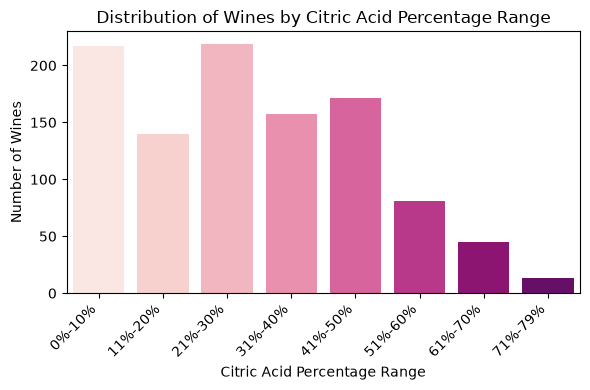

In [25]:
citric_acid_bins = [0, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.79]
citric_acid_labels = ['0%-10%', '11%-20%', '21%-30%', '31%-40%', '41%-50%', '51%-60%', '61%-70%', '71%-79%']
df_wineqt_2['faixa de perc acido citrico'] = pd.cut(df_wineqt_2['citric acid'], bins=citric_acid_bins, labels=citric_acid_labels, right=True)
plt.figure(figsize=(6, 4))
sns.countplot(x='faixa de perc acido citrico', data=df_wineqt_2, palette='RdPu', order=citric_acid_labels)
plt.title('Distribution of Wines by Citric Acid Percentage Range')
plt.xlabel('Citric Acid Percentage Range')
plt.ylabel('Number of Wines')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()